<a href="https://colab.research.google.com/github/swarajsah143/Broadway-Python/blob/main/Heart_Diseases_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data Preprocessing
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, MinMaxScaler

#Models ML
from sklearn.svm import SVC
#Metrics
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
# from sklearn.metrics import mean_squared_error,r2_score
# from sklearn.metrics import roc_curve, auc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/5:30-AI/heart_disease.csv')
data.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
row,col = data.shape
print("No of row = ",row)
print("No of col = ",col)


No of row =  10000
No of col =  21


In [ ]:
# There is not NaN or null values in columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [ ]:
data.isnull().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [ ]:
data = data.dropna()

In [ ]:
data.isnull().sum()

,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
BMI,0
High Blood Pressure,0


In [ ]:
data.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000,7067.000000
mean,49.301542,149.856092,224.722938,29.023933,6.982595,250.523136,119.966605,7.448118,12.444451
std,18.270030,17.606064,43.529500,6.276510,1.749378,87.051480,23.612628,4.358898,4.311619
min,18.000000,120.000000,150.000000,18.007058,4.000605,100.000000,80.000000,0.010585,5.002810
25%,34.000000,134.000000,187.000000,23.633185,5.459460,176.000000,99.000000,3.629919,8.723192
50%,49.000000,150.000000,224.000000,29.046381,6.982377,250.000000,120.000000,7.445087,12.428130
75%,65.000000,166.000000,262.000000,34.402934,8.519562,326.000000,141.000000,11.209659,16.100166
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [ ]:
select_col_df = data[['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours','Triglyceride Level','Fasting Blood Sugar','CRP Level','Homocysteine Level']]


In [ ]:
# corrs=select_col_df.corr()

In [ ]:
# corrs[corrs['Blood Pressure']>0.01]


In [ ]:
select_col_df.corr()


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
Age,1.000000,-0.012478,0.015486,0.019899,0.007324,-0.003861,-0.001104,0.003184,-0.017151
Blood Pressure,-0.012478,1.000000,-0.015947,0.002142,0.000510,0.005569,-0.009468,-0.014311,0.003297
Cholesterol Level,0.015486,-0.015947,1.000000,0.032988,0.000869,-0.000896,0.007003,-0.025941,-0.002825
BMI,0.019899,0.002142,0.032988,1.000000,-0.004871,0.009191,0.005788,-0.019908,-0.000540
Sleep Hours,0.007324,0.000510,0.000869,-0.004871,1.000000,0.007669,0.007226,0.007411,-0.024812
Triglyceride Level,-0.003861,0.005569,-0.000896,0.009191,0.007669,1.000000,0.015733,-0.005918,-0.005032
Fasting Blood Sugar,-0.001104,-0.009468,0.007003,0.005788,0.007226,0.015733,1.000000,0.009634,-0.025907
CRP Level,0.003184,-0.014311,-0.025941,-0.019908,0.007411,-0.005918,0.009634,1.000000,-0.009857
Homocysteine Level,-0.017151,0.003297,-0.002825,-0.000540,-0.024812,-0.005032,-0.025907,-0.009857,1.000000


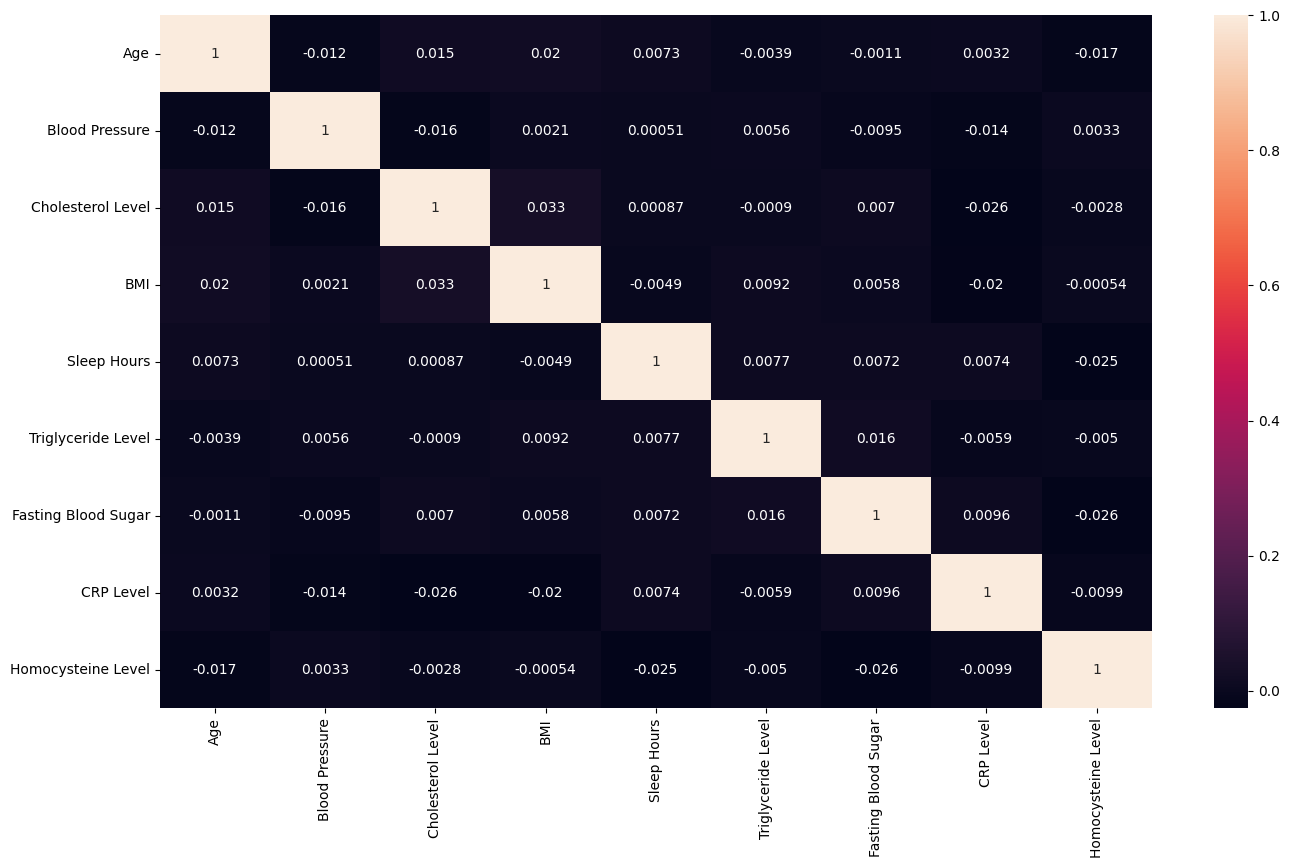

In [ ]:
plt.figure(figsize=(16,9))
corr = select_col_df.corr()
sns.heatmap(corr, annot=True)
plt.show()


In [ ]:
EH = pd.get_dummies(data['Exercise Habits'])
EH

,High,Low,Medium
1,True,False,False
2,False,True,False
3,True,False,False
4,False,True,False
5,False,True,False
...,...,...,...
9992,False,False,True
9994,False,False,True
9995,False,False,True
9998,False,True,False


In [ ]:
data = pd.concat([data, EH], axis = 1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,High,Low,Medium
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,8.744034,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,4.440440,Low,393.0,92.0,12.709873,11.230926,No,False,True,False
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,5.249405,High,293.0,94.0,12.509046,5.961958,No,True,False,False
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,7.030971,High,263.0,154.0,10.381259,8.153887,No,False,True,False
5,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,No,...,5.504876,Low,126.0,91.0,4.297575,10.815983,No,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,Medium,Yes,No,No,22.839718,No,...,6.057509,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True
9994,73.0,Female,144.0,191.0,Medium,Yes,Yes,Yes,39.459620,No,...,7.549114,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False


In [ ]:
data = data.rename(columns={"High":"Eating_Habits_High"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Low,Medium
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,8.744034,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,4.440440,Low,393.0,92.0,12.709873,11.230926,No,False,True,False
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,5.249405,High,293.0,94.0,12.509046,5.961958,No,True,False,False
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,7.030971,High,263.0,154.0,10.381259,8.153887,No,False,True,False
5,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,No,...,5.504876,Low,126.0,91.0,4.297575,10.815983,No,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,Medium,Yes,No,No,22.839718,No,...,6.057509,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True
9994,73.0,Female,144.0,191.0,Medium,Yes,Yes,Yes,39.459620,No,...,7.549114,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False


In [ ]:
data = data.rename(columns={"Low":"Eating_Habits_Low"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Medium
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,8.744034,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,4.440440,Low,393.0,92.0,12.709873,11.230926,No,False,True,False
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,5.249405,High,293.0,94.0,12.509046,5.961958,No,True,False,False
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,7.030971,High,263.0,154.0,10.381259,8.153887,No,False,True,False
5,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,No,...,5.504876,Low,126.0,91.0,4.297575,10.815983,No,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,Medium,Yes,No,No,22.839718,No,...,6.057509,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True
9994,73.0,Female,144.0,191.0,Medium,Yes,Yes,Yes,39.459620,No,...,7.549114,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False


In [ ]:
data = data.rename(columns={"Medium":"Eating_Habits_Medium"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,8.744034,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,4.440440,Low,393.0,92.0,12.709873,11.230926,No,False,True,False
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,5.249405,High,293.0,94.0,12.509046,5.961958,No,True,False,False
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,7.030971,High,263.0,154.0,10.381259,8.153887,No,False,True,False
5,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,No,...,5.504876,Low,126.0,91.0,4.297575,10.815983,No,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,Medium,Yes,No,No,22.839718,No,...,6.057509,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True
9994,73.0,Female,144.0,191.0,Medium,Yes,Yes,Yes,39.459620,No,...,7.549114,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False


In [ ]:
data=data.drop(['Exercise Habits'],axis = 1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,...,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium
1,69.0,Female,146.0,286.0,No,Yes,Yes,25.221799,No,Yes,...,8.744034,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False
2,46.0,Male,126.0,216.0,No,No,No,29.855447,No,Yes,...,4.440440,Low,393.0,92.0,12.709873,11.230926,No,False,True,False
3,32.0,Female,122.0,293.0,Yes,Yes,No,24.130477,Yes,No,...,5.249405,High,293.0,94.0,12.509046,5.961958,No,True,False,False
4,60.0,Male,166.0,242.0,Yes,Yes,Yes,20.486289,Yes,No,...,7.030971,High,263.0,154.0,10.381259,8.153887,No,False,True,False
5,25.0,Male,152.0,257.0,Yes,No,No,28.144681,No,No,...,5.504876,Low,126.0,91.0,4.297575,10.815983,No,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,Yes,No,No,22.839718,No,Yes,...,6.057509,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True
9994,73.0,Female,144.0,191.0,Yes,Yes,Yes,39.459620,No,No,...,7.549114,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True
9995,25.0,Female,136.0,243.0,Yes,No,No,18.788791,Yes,No,...,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True
9998,23.0,Male,142.0,299.0,Yes,No,Yes,34.964026,Yes,No,...,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False


In [ ]:
Smoking = pd.get_dummies(data['Smoking'],drop_first=True)
Smoking

,Yes
1,False
2,False
3,True
4,True
5,True
...,...
9992,True
9994,True
9995,True
9998,True


In [ ]:
data=pd.concat([data,Smoking],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,...,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Yes
1,69.0,Female,146.0,286.0,No,Yes,Yes,25.221799,No,Yes,...,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False,False
2,46.0,Male,126.0,216.0,No,No,No,29.855447,No,Yes,...,Low,393.0,92.0,12.709873,11.230926,No,False,True,False,False
3,32.0,Female,122.0,293.0,Yes,Yes,No,24.130477,Yes,No,...,High,293.0,94.0,12.509046,5.961958,No,True,False,False,True
4,60.0,Male,166.0,242.0,Yes,Yes,Yes,20.486289,Yes,No,...,High,263.0,154.0,10.381259,8.153887,No,False,True,False,True
5,25.0,Male,152.0,257.0,Yes,No,No,28.144681,No,No,...,Low,126.0,91.0,4.297575,10.815983,No,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,Yes,No,No,22.839718,No,Yes,...,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True,True
9994,73.0,Female,144.0,191.0,Yes,Yes,Yes,39.459620,No,No,...,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True,True
9995,25.0,Female,136.0,243.0,Yes,No,No,18.788791,Yes,No,...,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True,True
9998,23.0,Male,142.0,299.0,Yes,No,Yes,34.964026,Yes,No,...,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False,True


In [ ]:
data = data.rename(columns={"Smoking":"Smokings"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,Smokings,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,...,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Yes
1,69.0,Female,146.0,286.0,No,Yes,Yes,25.221799,No,Yes,...,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False,False
2,46.0,Male,126.0,216.0,No,No,No,29.855447,No,Yes,...,Low,393.0,92.0,12.709873,11.230926,No,False,True,False,False
3,32.0,Female,122.0,293.0,Yes,Yes,No,24.130477,Yes,No,...,High,293.0,94.0,12.509046,5.961958,No,True,False,False,True
4,60.0,Male,166.0,242.0,Yes,Yes,Yes,20.486289,Yes,No,...,High,263.0,154.0,10.381259,8.153887,No,False,True,False,True
5,25.0,Male,152.0,257.0,Yes,No,No,28.144681,No,No,...,Low,126.0,91.0,4.297575,10.815983,No,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,Yes,No,No,22.839718,No,Yes,...,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True,True
9994,73.0,Female,144.0,191.0,Yes,Yes,Yes,39.459620,No,No,...,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True,True
9995,25.0,Female,136.0,243.0,Yes,No,No,18.788791,Yes,No,...,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True,True
9998,23.0,Male,142.0,299.0,Yes,No,Yes,34.964026,Yes,No,...,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False,True


In [ ]:
data = data.rename(columns={"Yes":"Smoking"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,Smokings,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,...,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking
1,69.0,Female,146.0,286.0,No,Yes,Yes,25.221799,No,Yes,...,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False,False
2,46.0,Male,126.0,216.0,No,No,No,29.855447,No,Yes,...,Low,393.0,92.0,12.709873,11.230926,No,False,True,False,False
3,32.0,Female,122.0,293.0,Yes,Yes,No,24.130477,Yes,No,...,High,293.0,94.0,12.509046,5.961958,No,True,False,False,True
4,60.0,Male,166.0,242.0,Yes,Yes,Yes,20.486289,Yes,No,...,High,263.0,154.0,10.381259,8.153887,No,False,True,False,True
5,25.0,Male,152.0,257.0,Yes,No,No,28.144681,No,No,...,Low,126.0,91.0,4.297575,10.815983,No,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,Yes,No,No,22.839718,No,Yes,...,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True,True
9994,73.0,Female,144.0,191.0,Yes,Yes,Yes,39.459620,No,No,...,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True,True
9995,25.0,Female,136.0,243.0,Yes,No,No,18.788791,Yes,No,...,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True,True
9998,23.0,Male,142.0,299.0,Yes,No,Yes,34.964026,Yes,No,...,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False,True


In [ ]:
data=data.drop(['Smokings'],axis = 1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,...,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking
1,69.0,Female,146.0,286.0,Yes,Yes,25.221799,No,Yes,No,...,Medium,133.0,157.0,9.355389,19.298875,No,True,False,False,False
2,46.0,Male,126.0,216.0,No,No,29.855447,No,Yes,Yes,...,Low,393.0,92.0,12.709873,11.230926,No,False,True,False,False
3,32.0,Female,122.0,293.0,Yes,No,24.130477,Yes,No,Yes,...,High,293.0,94.0,12.509046,5.961958,No,True,False,False,True
4,60.0,Male,166.0,242.0,Yes,Yes,20.486289,Yes,No,No,...,High,263.0,154.0,10.381259,8.153887,No,False,True,False,True
5,25.0,Male,152.0,257.0,No,No,28.144681,No,No,No,...,Low,126.0,91.0,4.297575,10.815983,No,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,No,No,22.839718,No,Yes,No,...,High,299.0,142.0,3.321020,11.910244,Yes,False,False,True,True
9994,73.0,Female,144.0,191.0,Yes,Yes,39.459620,No,No,No,...,Medium,200.0,88.0,1.154904,8.021732,Yes,False,False,True,True
9995,25.0,Female,136.0,243.0,No,No,18.788791,Yes,No,Yes,...,Medium,343.0,133.0,3.588814,19.132004,Yes,False,False,True,True
9998,23.0,Male,142.0,299.0,No,Yes,34.964026,Yes,No,Yes,...,Medium,113.0,153.0,7.215634,11.873486,Yes,False,True,False,True


In [ ]:
Diabetes = pd.get_dummies(data['Diabetes'],drop_first=True)
Diabetes

,Yes
1,True
2,False
3,False
4,True
5,False
...,...
9992,False
9994,True
9995,False
9998,True


In [ ]:
data=pd.concat([data,Diabetes],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,...,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Yes
1,69.0,Female,146.0,286.0,Yes,Yes,25.221799,No,Yes,No,...,133.0,157.0,9.355389,19.298875,No,True,False,False,False,True
2,46.0,Male,126.0,216.0,No,No,29.855447,No,Yes,Yes,...,393.0,92.0,12.709873,11.230926,No,False,True,False,False,False
3,32.0,Female,122.0,293.0,Yes,No,24.130477,Yes,No,Yes,...,293.0,94.0,12.509046,5.961958,No,True,False,False,True,False
4,60.0,Male,166.0,242.0,Yes,Yes,20.486289,Yes,No,No,...,263.0,154.0,10.381259,8.153887,No,False,True,False,True,True
5,25.0,Male,152.0,257.0,No,No,28.144681,No,No,No,...,126.0,91.0,4.297575,10.815983,No,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,No,No,22.839718,No,Yes,No,...,299.0,142.0,3.321020,11.910244,Yes,False,False,True,True,False
9994,73.0,Female,144.0,191.0,Yes,Yes,39.459620,No,No,No,...,200.0,88.0,1.154904,8.021732,Yes,False,False,True,True,True
9995,25.0,Female,136.0,243.0,No,No,18.788791,Yes,No,Yes,...,343.0,133.0,3.588814,19.132004,Yes,False,False,True,True,False
9998,23.0,Male,142.0,299.0,No,Yes,34.964026,Yes,No,Yes,...,113.0,153.0,7.215634,11.873486,Yes,False,True,False,True,True


In [ ]:
data=data.drop(['Diabetes'],axis = 1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Family Heart Disease,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,...,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Yes
1,69.0,Female,146.0,286.0,Yes,25.221799,No,Yes,No,Medium,...,133.0,157.0,9.355389,19.298875,No,True,False,False,False,True
2,46.0,Male,126.0,216.0,No,29.855447,No,Yes,Yes,Low,...,393.0,92.0,12.709873,11.230926,No,False,True,False,False,False
3,32.0,Female,122.0,293.0,Yes,24.130477,Yes,No,Yes,Low,...,293.0,94.0,12.509046,5.961958,No,True,False,False,True,False
4,60.0,Male,166.0,242.0,Yes,20.486289,Yes,No,No,Low,...,263.0,154.0,10.381259,8.153887,No,False,True,False,True,True
5,25.0,Male,152.0,257.0,No,28.144681,No,No,No,Low,...,126.0,91.0,4.297575,10.815983,No,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,No,22.839718,No,Yes,No,Medium,...,299.0,142.0,3.321020,11.910244,Yes,False,False,True,True,False
9994,73.0,Female,144.0,191.0,Yes,39.459620,No,No,No,Medium,...,200.0,88.0,1.154904,8.021732,Yes,False,False,True,True,True
9995,25.0,Female,136.0,243.0,No,18.788791,Yes,No,Yes,Medium,...,343.0,133.0,3.588814,19.132004,Yes,False,False,True,True,False
9998,23.0,Male,142.0,299.0,No,34.964026,Yes,No,Yes,Medium,...,113.0,153.0,7.215634,11.873486,Yes,False,True,False,True,True


In [ ]:
data = data.rename(columns={"Yes":"Diabetes"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,Family Heart Disease,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,...,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes
1,69.0,Female,146.0,286.0,Yes,25.221799,No,Yes,No,Medium,...,133.0,157.0,9.355389,19.298875,No,True,False,False,False,True
2,46.0,Male,126.0,216.0,No,29.855447,No,Yes,Yes,Low,...,393.0,92.0,12.709873,11.230926,No,False,True,False,False,False
3,32.0,Female,122.0,293.0,Yes,24.130477,Yes,No,Yes,Low,...,293.0,94.0,12.509046,5.961958,No,True,False,False,True,False
4,60.0,Male,166.0,242.0,Yes,20.486289,Yes,No,No,Low,...,263.0,154.0,10.381259,8.153887,No,False,True,False,True,True
5,25.0,Male,152.0,257.0,No,28.144681,No,No,No,Low,...,126.0,91.0,4.297575,10.815983,No,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,No,22.839718,No,Yes,No,Medium,...,299.0,142.0,3.321020,11.910244,Yes,False,False,True,True,False
9994,73.0,Female,144.0,191.0,Yes,39.459620,No,No,No,Medium,...,200.0,88.0,1.154904,8.021732,Yes,False,False,True,True,True
9995,25.0,Female,136.0,243.0,No,18.788791,Yes,No,Yes,Medium,...,343.0,133.0,3.588814,19.132004,Yes,False,False,True,True,False
9998,23.0,Male,142.0,299.0,No,34.964026,Yes,No,Yes,Medium,...,113.0,153.0,7.215634,11.873486,Yes,False,True,False,True,True


In [ ]:
FHD=pd.get_dummies(data['Family Heart Disease'],drop_first=True)
FHD

,Yes
1,True
2,False
3,True
4,True
5,False
...,...
9992,False
9994,True
9995,False
9998,False


In [ ]:
data= pd.concat([data,FHD],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,Family Heart Disease,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,...,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Yes
1,69.0,Female,146.0,286.0,Yes,25.221799,No,Yes,No,Medium,...,157.0,9.355389,19.298875,No,True,False,False,False,True,True
2,46.0,Male,126.0,216.0,No,29.855447,No,Yes,Yes,Low,...,92.0,12.709873,11.230926,No,False,True,False,False,False,False
3,32.0,Female,122.0,293.0,Yes,24.130477,Yes,No,Yes,Low,...,94.0,12.509046,5.961958,No,True,False,False,True,False,True
4,60.0,Male,166.0,242.0,Yes,20.486289,Yes,No,No,Low,...,154.0,10.381259,8.153887,No,False,True,False,True,True,True
5,25.0,Male,152.0,257.0,No,28.144681,No,No,No,Low,...,91.0,4.297575,10.815983,No,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,No,22.839718,No,Yes,No,Medium,...,142.0,3.321020,11.910244,Yes,False,False,True,True,False,False
9994,73.0,Female,144.0,191.0,Yes,39.459620,No,No,No,Medium,...,88.0,1.154904,8.021732,Yes,False,False,True,True,True,True
9995,25.0,Female,136.0,243.0,No,18.788791,Yes,No,Yes,Medium,...,133.0,3.588814,19.132004,Yes,False,False,True,True,False,False
9998,23.0,Male,142.0,299.0,No,34.964026,Yes,No,Yes,Medium,...,153.0,7.215634,11.873486,Yes,False,True,False,True,True,False


In [ ]:
data=data.drop(["Family Heart Disease"],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,...,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Yes
1,69.0,Female,146.0,286.0,25.221799,No,Yes,No,Medium,High,...,157.0,9.355389,19.298875,No,True,False,False,False,True,True
2,46.0,Male,126.0,216.0,29.855447,No,Yes,Yes,Low,Low,...,92.0,12.709873,11.230926,No,False,True,False,False,False,False
3,32.0,Female,122.0,293.0,24.130477,Yes,No,Yes,Low,High,...,94.0,12.509046,5.961958,No,True,False,False,True,False,True
4,60.0,Male,166.0,242.0,20.486289,Yes,No,No,Low,High,...,154.0,10.381259,8.153887,No,False,True,False,True,True,True
5,25.0,Male,152.0,257.0,28.144681,No,No,No,Low,Medium,...,91.0,4.297575,10.815983,No,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,No,Yes,No,Medium,Low,...,142.0,3.321020,11.910244,Yes,False,False,True,True,False,False
9994,73.0,Female,144.0,191.0,39.459620,No,No,No,Medium,Low,...,88.0,1.154904,8.021732,Yes,False,False,True,True,True,True
9995,25.0,Female,136.0,243.0,18.788791,Yes,No,Yes,Medium,High,...,133.0,3.588814,19.132004,Yes,False,False,True,True,False,False
9998,23.0,Male,142.0,299.0,34.964026,Yes,No,Yes,Medium,High,...,153.0,7.215634,11.873486,Yes,False,True,False,True,True,False


In [ ]:
data= data.rename(columns={"Yes": "Family_Heart_Disease"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,...,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease
1,69.0,Female,146.0,286.0,25.221799,No,Yes,No,Medium,High,...,157.0,9.355389,19.298875,No,True,False,False,False,True,True
2,46.0,Male,126.0,216.0,29.855447,No,Yes,Yes,Low,Low,...,92.0,12.709873,11.230926,No,False,True,False,False,False,False
3,32.0,Female,122.0,293.0,24.130477,Yes,No,Yes,Low,High,...,94.0,12.509046,5.961958,No,True,False,False,True,False,True
4,60.0,Male,166.0,242.0,20.486289,Yes,No,No,Low,High,...,154.0,10.381259,8.153887,No,False,True,False,True,True,True
5,25.0,Male,152.0,257.0,28.144681,No,No,No,Low,Medium,...,91.0,4.297575,10.815983,No,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,No,Yes,No,Medium,Low,...,142.0,3.321020,11.910244,Yes,False,False,True,True,False,False
9994,73.0,Female,144.0,191.0,39.459620,No,No,No,Medium,Low,...,88.0,1.154904,8.021732,Yes,False,False,True,True,True,True
9995,25.0,Female,136.0,243.0,18.788791,Yes,No,Yes,Medium,High,...,133.0,3.588814,19.132004,Yes,False,False,True,True,False,False
9998,23.0,Male,142.0,299.0,34.964026,Yes,No,Yes,Medium,High,...,153.0,7.215634,11.873486,Yes,False,True,False,True,True,False


In [ ]:
HBP= pd.get_dummies(data["High Blood Pressure"],drop_first=True)
HBP

,Yes
1,False
2,False
3,True
4,True
5,False
...,...
9992,False
9994,False
9995,True
9998,True


In [ ]:
data=pd.concat([data,HBP],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,...,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,Yes
1,69.0,Female,146.0,286.0,25.221799,No,Yes,No,Medium,High,...,9.355389,19.298875,No,True,False,False,False,True,True,False
2,46.0,Male,126.0,216.0,29.855447,No,Yes,Yes,Low,Low,...,12.709873,11.230926,No,False,True,False,False,False,False,False
3,32.0,Female,122.0,293.0,24.130477,Yes,No,Yes,Low,High,...,12.509046,5.961958,No,True,False,False,True,False,True,True
4,60.0,Male,166.0,242.0,20.486289,Yes,No,No,Low,High,...,10.381259,8.153887,No,False,True,False,True,True,True,True
5,25.0,Male,152.0,257.0,28.144681,No,No,No,Low,Medium,...,4.297575,10.815983,No,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,No,Yes,No,Medium,Low,...,3.321020,11.910244,Yes,False,False,True,True,False,False,False
9994,73.0,Female,144.0,191.0,39.459620,No,No,No,Medium,Low,...,1.154904,8.021732,Yes,False,False,True,True,True,True,False
9995,25.0,Female,136.0,243.0,18.788791,Yes,No,Yes,Medium,High,...,3.588814,19.132004,Yes,False,False,True,True,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,Yes,No,Yes,Medium,High,...,7.215634,11.873486,Yes,False,True,False,True,True,False,True


In [ ]:
data= data.drop(["High Blood Pressure"],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,...,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,Yes
1,69.0,Female,146.0,286.0,25.221799,Yes,No,Medium,High,8.744034,...,9.355389,19.298875,No,True,False,False,False,True,True,False
2,46.0,Male,126.0,216.0,29.855447,Yes,Yes,Low,Low,4.440440,...,12.709873,11.230926,No,False,True,False,False,False,False,False
3,32.0,Female,122.0,293.0,24.130477,No,Yes,Low,High,5.249405,...,12.509046,5.961958,No,True,False,False,True,False,True,True
4,60.0,Male,166.0,242.0,20.486289,No,No,Low,High,7.030971,...,10.381259,8.153887,No,False,True,False,True,True,True,True
5,25.0,Male,152.0,257.0,28.144681,No,No,Low,Medium,5.504876,...,4.297575,10.815983,No,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Yes,No,Medium,Low,6.057509,...,3.321020,11.910244,Yes,False,False,True,True,False,False,False
9994,73.0,Female,144.0,191.0,39.459620,No,No,Medium,Low,7.549114,...,1.154904,8.021732,Yes,False,False,True,True,True,True,False
9995,25.0,Female,136.0,243.0,18.788791,No,Yes,Medium,High,6.834954,...,3.588814,19.132004,Yes,False,False,True,True,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,No,Yes,Medium,High,8.526329,...,7.215634,11.873486,Yes,False,True,False,True,True,False,True


In [ ]:
data= data.rename(columns={"Yes":"High Blood Pressure"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,...,CRP Level,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure
1,69.0,Female,146.0,286.0,25.221799,Yes,No,Medium,High,8.744034,...,9.355389,19.298875,No,True,False,False,False,True,True,False
2,46.0,Male,126.0,216.0,29.855447,Yes,Yes,Low,Low,4.440440,...,12.709873,11.230926,No,False,True,False,False,False,False,False
3,32.0,Female,122.0,293.0,24.130477,No,Yes,Low,High,5.249405,...,12.509046,5.961958,No,True,False,False,True,False,True,True
4,60.0,Male,166.0,242.0,20.486289,No,No,Low,High,7.030971,...,10.381259,8.153887,No,False,True,False,True,True,True,True
5,25.0,Male,152.0,257.0,28.144681,No,No,Low,Medium,5.504876,...,4.297575,10.815983,No,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Yes,No,Medium,Low,6.057509,...,3.321020,11.910244,Yes,False,False,True,True,False,False,False
9994,73.0,Female,144.0,191.0,39.459620,No,No,Medium,Low,7.549114,...,1.154904,8.021732,Yes,False,False,True,True,True,True,False
9995,25.0,Female,136.0,243.0,18.788791,No,Yes,Medium,High,6.834954,...,3.588814,19.132004,Yes,False,False,True,True,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,No,Yes,Medium,High,8.526329,...,7.215634,11.873486,Yes,False,True,False,True,True,False,True


In [ ]:
Low_HDL_Cholesterol= pd.get_dummies(data["Low HDL Cholesterol"],drop_first=True)
Low_HDL_Cholesterol

,Yes
1,True
2,True
3,False
4,False
5,False
...,...
9992,True
9994,False
9995,False
9998,False


In [ ]:
data=pd.concat([data,Low_HDL_Cholesterol],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,...,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Yes
1,69.0,Female,146.0,286.0,25.221799,Yes,No,Medium,High,8.744034,...,19.298875,No,True,False,False,False,True,True,False,True
2,46.0,Male,126.0,216.0,29.855447,Yes,Yes,Low,Low,4.440440,...,11.230926,No,False,True,False,False,False,False,False,True
3,32.0,Female,122.0,293.0,24.130477,No,Yes,Low,High,5.249405,...,5.961958,No,True,False,False,True,False,True,True,False
4,60.0,Male,166.0,242.0,20.486289,No,No,Low,High,7.030971,...,8.153887,No,False,True,False,True,True,True,True,False
5,25.0,Male,152.0,257.0,28.144681,No,No,Low,Medium,5.504876,...,10.815983,No,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Yes,No,Medium,Low,6.057509,...,11.910244,Yes,False,False,True,True,False,False,False,True
9994,73.0,Female,144.0,191.0,39.459620,No,No,Medium,Low,7.549114,...,8.021732,Yes,False,False,True,True,True,True,False,False
9995,25.0,Female,136.0,243.0,18.788791,No,Yes,Medium,High,6.834954,...,19.132004,Yes,False,False,True,True,False,False,True,False
9998,23.0,Male,142.0,299.0,34.964026,No,Yes,Medium,High,8.526329,...,11.873486,Yes,False,True,False,True,True,False,True,False


In [ ]:
data= data.drop(["Low HDL Cholesterol"],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,...,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Yes
1,69.0,Female,146.0,286.0,25.221799,No,Medium,High,8.744034,Medium,...,19.298875,No,True,False,False,False,True,True,False,True
2,46.0,Male,126.0,216.0,29.855447,Yes,Low,Low,4.440440,Low,...,11.230926,No,False,True,False,False,False,False,False,True
3,32.0,Female,122.0,293.0,24.130477,Yes,Low,High,5.249405,High,...,5.961958,No,True,False,False,True,False,True,True,False
4,60.0,Male,166.0,242.0,20.486289,No,Low,High,7.030971,High,...,8.153887,No,False,True,False,True,True,True,True,False
5,25.0,Male,152.0,257.0,28.144681,No,Low,Medium,5.504876,Low,...,10.815983,No,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,No,Medium,Low,6.057509,High,...,11.910244,Yes,False,False,True,True,False,False,False,True
9994,73.0,Female,144.0,191.0,39.459620,No,Medium,Low,7.549114,Medium,...,8.021732,Yes,False,False,True,True,True,True,False,False
9995,25.0,Female,136.0,243.0,18.788791,Yes,Medium,High,6.834954,Medium,...,19.132004,Yes,False,False,True,True,False,False,True,False
9998,23.0,Male,142.0,299.0,34.964026,Yes,Medium,High,8.526329,Medium,...,11.873486,Yes,False,True,False,True,True,False,True,False


In [ ]:
data= data.rename(columns={"Yes":"Low HDL Cholesterol"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,...,Homocysteine Level,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol
1,69.0,Female,146.0,286.0,25.221799,No,Medium,High,8.744034,Medium,...,19.298875,No,True,False,False,False,True,True,False,True
2,46.0,Male,126.0,216.0,29.855447,Yes,Low,Low,4.440440,Low,...,11.230926,No,False,True,False,False,False,False,False,True
3,32.0,Female,122.0,293.0,24.130477,Yes,Low,High,5.249405,High,...,5.961958,No,True,False,False,True,False,True,True,False
4,60.0,Male,166.0,242.0,20.486289,No,Low,High,7.030971,High,...,8.153887,No,False,True,False,True,True,True,True,False
5,25.0,Male,152.0,257.0,28.144681,No,Low,Medium,5.504876,Low,...,10.815983,No,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,No,Medium,Low,6.057509,High,...,11.910244,Yes,False,False,True,True,False,False,False,True
9994,73.0,Female,144.0,191.0,39.459620,No,Medium,Low,7.549114,Medium,...,8.021732,Yes,False,False,True,True,True,True,False,False
9995,25.0,Female,136.0,243.0,18.788791,Yes,Medium,High,6.834954,Medium,...,19.132004,Yes,False,False,True,True,False,False,True,False
9998,23.0,Male,142.0,299.0,34.964026,Yes,Medium,High,8.526329,Medium,...,11.873486,Yes,False,True,False,True,True,False,True,False


In [ ]:
High_HDL_Cholesterol= pd.get_dummies(data["High LDL Cholesterol"],drop_first=True)
High_HDL_Cholesterol

,Yes
1,False
2,True
3,True
4,False
5,False
...,...
9992,False
9994,False
9995,True
9998,True


In [ ]:
data=pd.concat([data,High_HDL_Cholesterol],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,...,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,Yes
1,69.0,Female,146.0,286.0,25.221799,No,Medium,High,8.744034,Medium,...,No,True,False,False,False,True,True,False,True,False
2,46.0,Male,126.0,216.0,29.855447,Yes,Low,Low,4.440440,Low,...,No,False,True,False,False,False,False,False,True,True
3,32.0,Female,122.0,293.0,24.130477,Yes,Low,High,5.249405,High,...,No,True,False,False,True,False,True,True,False,True
4,60.0,Male,166.0,242.0,20.486289,No,Low,High,7.030971,High,...,No,False,True,False,True,True,True,True,False,False
5,25.0,Male,152.0,257.0,28.144681,No,Low,Medium,5.504876,Low,...,No,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,No,Medium,Low,6.057509,High,...,Yes,False,False,True,True,False,False,False,True,False
9994,73.0,Female,144.0,191.0,39.459620,No,Medium,Low,7.549114,Medium,...,Yes,False,False,True,True,True,True,False,False,False
9995,25.0,Female,136.0,243.0,18.788791,Yes,Medium,High,6.834954,Medium,...,Yes,False,False,True,True,False,False,True,False,True
9998,23.0,Male,142.0,299.0,34.964026,Yes,Medium,High,8.526329,Medium,...,Yes,False,True,False,True,True,False,True,False,True


In [ ]:
data= data.drop(["High LDL Cholesterol"],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,...,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,Yes
1,69.0,Female,146.0,286.0,25.221799,Medium,High,8.744034,Medium,133.0,...,No,True,False,False,False,True,True,False,True,False
2,46.0,Male,126.0,216.0,29.855447,Low,Low,4.440440,Low,393.0,...,No,False,True,False,False,False,False,False,True,True
3,32.0,Female,122.0,293.0,24.130477,Low,High,5.249405,High,293.0,...,No,True,False,False,True,False,True,True,False,True
4,60.0,Male,166.0,242.0,20.486289,Low,High,7.030971,High,263.0,...,No,False,True,False,True,True,True,True,False,False
5,25.0,Male,152.0,257.0,28.144681,Low,Medium,5.504876,Low,126.0,...,No,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Medium,Low,6.057509,High,299.0,...,Yes,False,False,True,True,False,False,False,True,False
9994,73.0,Female,144.0,191.0,39.459620,Medium,Low,7.549114,Medium,200.0,...,Yes,False,False,True,True,True,True,False,False,False
9995,25.0,Female,136.0,243.0,18.788791,Medium,High,6.834954,Medium,343.0,...,Yes,False,False,True,True,False,False,True,False,True
9998,23.0,Male,142.0,299.0,34.964026,Medium,High,8.526329,Medium,113.0,...,Yes,False,True,False,True,True,False,True,False,True


In [ ]:
data= data.rename(columns={"Yes":"High LDL Cholesterol"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,...,Heart Disease Status,Eating_Habits_High,Eating_Habits_Low,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol
1,69.0,Female,146.0,286.0,25.221799,Medium,High,8.744034,Medium,133.0,...,No,True,False,False,False,True,True,False,True,False
2,46.0,Male,126.0,216.0,29.855447,Low,Low,4.440440,Low,393.0,...,No,False,True,False,False,False,False,False,True,True
3,32.0,Female,122.0,293.0,24.130477,Low,High,5.249405,High,293.0,...,No,True,False,False,True,False,True,True,False,True
4,60.0,Male,166.0,242.0,20.486289,Low,High,7.030971,High,263.0,...,No,False,True,False,True,True,True,True,False,False
5,25.0,Male,152.0,257.0,28.144681,Low,Medium,5.504876,Low,126.0,...,No,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Medium,Low,6.057509,High,299.0,...,Yes,False,False,True,True,False,False,False,True,False
9994,73.0,Female,144.0,191.0,39.459620,Medium,Low,7.549114,Medium,200.0,...,Yes,False,False,True,True,True,True,False,False,False
9995,25.0,Female,136.0,243.0,18.788791,Medium,High,6.834954,Medium,343.0,...,Yes,False,False,True,True,False,False,True,False,True
9998,23.0,Male,142.0,299.0,34.964026,Medium,High,8.526329,Medium,113.0,...,Yes,False,True,False,True,True,False,True,False,True


In [ ]:
Alcohol_Consumption= pd.get_dummies(data["Alcohol Consumption"])
Alcohol_Consumption

,High,Low,Medium
1,False,False,True
2,False,True,False
3,False,True,False
4,False,True,False
5,False,True,False
...,...,...,...
9992,False,False,True
9994,False,False,True
9995,False,False,True
9998,False,False,True


In [ ]:
data=pd.concat([data,Alcohol_Consumption],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,...,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,High,Low,Medium
1,69.0,Female,146.0,286.0,25.221799,Medium,High,8.744034,Medium,133.0,...,False,False,True,True,False,True,False,False,False,True
2,46.0,Male,126.0,216.0,29.855447,Low,Low,4.440440,Low,393.0,...,False,False,False,False,False,True,True,False,True,False
3,32.0,Female,122.0,293.0,24.130477,Low,High,5.249405,High,293.0,...,False,True,False,True,True,False,True,False,True,False
4,60.0,Male,166.0,242.0,20.486289,Low,High,7.030971,High,263.0,...,False,True,True,True,True,False,False,False,True,False
5,25.0,Male,152.0,257.0,28.144681,Low,Medium,5.504876,Low,126.0,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Medium,Low,6.057509,High,299.0,...,True,True,False,False,False,True,False,False,False,True
9994,73.0,Female,144.0,191.0,39.459620,Medium,Low,7.549114,Medium,200.0,...,True,True,True,True,False,False,False,False,False,True
9995,25.0,Female,136.0,243.0,18.788791,Medium,High,6.834954,Medium,343.0,...,True,True,False,False,True,False,True,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,Medium,High,8.526329,Medium,113.0,...,False,True,True,False,True,False,True,False,False,True


In [ ]:
data= data.rename(columns={"High":"High Alcohol Consumption","Low":"Low Alcohol Consumption","Medium":"Medium Alcohol Consumption"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,...,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption
1,69.0,Female,146.0,286.0,25.221799,Medium,High,8.744034,Medium,133.0,...,False,False,True,True,False,True,False,False,False,True
2,46.0,Male,126.0,216.0,29.855447,Low,Low,4.440440,Low,393.0,...,False,False,False,False,False,True,True,False,True,False
3,32.0,Female,122.0,293.0,24.130477,Low,High,5.249405,High,293.0,...,False,True,False,True,True,False,True,False,True,False
4,60.0,Male,166.0,242.0,20.486289,Low,High,7.030971,High,263.0,...,False,True,True,True,True,False,False,False,True,False
5,25.0,Male,152.0,257.0,28.144681,Low,Medium,5.504876,Low,126.0,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Medium,Low,6.057509,High,299.0,...,True,True,False,False,False,True,False,False,False,True
9994,73.0,Female,144.0,191.0,39.459620,Medium,Low,7.549114,Medium,200.0,...,True,True,True,True,False,False,False,False,False,True
9995,25.0,Female,136.0,243.0,18.788791,Medium,High,6.834954,Medium,343.0,...,True,True,False,False,True,False,True,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,Medium,High,8.526329,Medium,113.0,...,False,True,True,False,True,False,True,False,False,True


In [ ]:
data= data.drop(["Alcohol Consumption"],axis=1)
data


,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,...,Eating_Habits_Medium,Smoking,Diabetes,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption
1,69.0,Female,146.0,286.0,25.221799,High,8.744034,Medium,133.0,157.0,...,False,False,True,True,False,True,False,False,False,True
2,46.0,Male,126.0,216.0,29.855447,Low,4.440440,Low,393.0,92.0,...,False,False,False,False,False,True,True,False,True,False
3,32.0,Female,122.0,293.0,24.130477,High,5.249405,High,293.0,94.0,...,False,True,False,True,True,False,True,False,True,False
4,60.0,Male,166.0,242.0,20.486289,High,7.030971,High,263.0,154.0,...,False,True,True,True,True,False,False,False,True,False
5,25.0,Male,152.0,257.0,28.144681,Medium,5.504876,Low,126.0,91.0,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Low,6.057509,High,299.0,142.0,...,True,True,False,False,False,True,False,False,False,True
9994,73.0,Female,144.0,191.0,39.459620,Low,7.549114,Medium,200.0,88.0,...,True,True,True,True,False,False,False,False,False,True
9995,25.0,Female,136.0,243.0,18.788791,High,6.834954,Medium,343.0,133.0,...,True,True,False,False,True,False,True,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,High,8.526329,Medium,113.0,153.0,...,False,True,True,False,True,False,True,False,False,True


In [ ]:
Stress_level= pd.get_dummies(data["Stress Level"])
Stress_level

,High,Low,Medium
1,True,False,False
2,False,True,False
3,True,False,False
4,True,False,False
5,False,False,True
...,...,...,...
9992,False,True,False
9994,False,True,False
9995,True,False,False
9998,True,False,False


In [ ]:
data=pd.concat([data,Stress_level],axis=1)
data


,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,...,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High,Low,Medium
1,69.0,Female,146.0,286.0,25.221799,High,8.744034,Medium,133.0,157.0,...,True,False,True,False,False,False,True,True,False,False
2,46.0,Male,126.0,216.0,29.855447,Low,4.440440,Low,393.0,92.0,...,False,False,True,True,False,True,False,False,True,False
3,32.0,Female,122.0,293.0,24.130477,High,5.249405,High,293.0,94.0,...,True,True,False,True,False,True,False,True,False,False
4,60.0,Male,166.0,242.0,20.486289,High,7.030971,High,263.0,154.0,...,True,True,False,False,False,True,False,True,False,False
5,25.0,Male,152.0,257.0,28.144681,Medium,5.504876,Low,126.0,91.0,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Low,6.057509,High,299.0,142.0,...,False,False,True,False,False,False,True,False,True,False
9994,73.0,Female,144.0,191.0,39.459620,Low,7.549114,Medium,200.0,88.0,...,True,False,False,False,False,False,True,False,True,False
9995,25.0,Female,136.0,243.0,18.788791,High,6.834954,Medium,343.0,133.0,...,False,True,False,True,False,False,True,True,False,False
9998,23.0,Male,142.0,299.0,34.964026,High,8.526329,Medium,113.0,153.0,...,False,True,False,True,False,False,True,True,False,False


In [ ]:
data= data.rename(columns={"High":"High Stress Level","Medium":"Medium Stress Level","Low":"Low Stress Level"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,...,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level
1,69.0,Female,146.0,286.0,25.221799,High,8.744034,Medium,133.0,157.0,...,True,False,True,False,False,False,True,True,False,False
2,46.0,Male,126.0,216.0,29.855447,Low,4.440440,Low,393.0,92.0,...,False,False,True,True,False,True,False,False,True,False
3,32.0,Female,122.0,293.0,24.130477,High,5.249405,High,293.0,94.0,...,True,True,False,True,False,True,False,True,False,False
4,60.0,Male,166.0,242.0,20.486289,High,7.030971,High,263.0,154.0,...,True,True,False,False,False,True,False,True,False,False
5,25.0,Male,152.0,257.0,28.144681,Medium,5.504876,Low,126.0,91.0,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,Low,6.057509,High,299.0,142.0,...,False,False,True,False,False,False,True,False,True,False
9994,73.0,Female,144.0,191.0,39.459620,Low,7.549114,Medium,200.0,88.0,...,True,False,False,False,False,False,True,False,True,False
9995,25.0,Female,136.0,243.0,18.788791,High,6.834954,Medium,343.0,133.0,...,False,True,False,True,False,False,True,True,False,False
9998,23.0,Male,142.0,299.0,34.964026,High,8.526329,Medium,113.0,153.0,...,False,True,False,True,False,False,True,True,False,False


In [ ]:
data= data.drop(["Stress Level"],axis=1)
data


,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,...,Family_Heart_Disease,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level
1,69.0,Female,146.0,286.0,25.221799,8.744034,Medium,133.0,157.0,9.355389,...,True,False,True,False,False,False,True,True,False,False
2,46.0,Male,126.0,216.0,29.855447,4.440440,Low,393.0,92.0,12.709873,...,False,False,True,True,False,True,False,False,True,False
3,32.0,Female,122.0,293.0,24.130477,5.249405,High,293.0,94.0,12.509046,...,True,True,False,True,False,True,False,True,False,False
4,60.0,Male,166.0,242.0,20.486289,7.030971,High,263.0,154.0,10.381259,...,True,True,False,False,False,True,False,True,False,False
5,25.0,Male,152.0,257.0,28.144681,5.504876,Low,126.0,91.0,4.297575,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,6.057509,High,299.0,142.0,3.321020,...,False,False,True,False,False,False,True,False,True,False
9994,73.0,Female,144.0,191.0,39.459620,7.549114,Medium,200.0,88.0,1.154904,...,True,False,False,False,False,False,True,False,True,False
9995,25.0,Female,136.0,243.0,18.788791,6.834954,Medium,343.0,133.0,3.588814,...,False,True,False,True,False,False,True,True,False,False
9998,23.0,Male,142.0,299.0,34.964026,8.526329,Medium,113.0,153.0,7.215634,...,False,True,False,True,False,False,True,True,False,False


In [ ]:
Sugar_Consumption= pd.get_dummies(data["Sugar Consumption"])
Sugar_Consumption

,High,Low,Medium
1,False,False,True
2,False,True,False
3,True,False,False
4,True,False,False
5,False,True,False
...,...,...,...
9992,True,False,False
9994,False,False,True
9995,False,False,True
9998,False,False,True


In [ ]:
data=pd.concat([data,Sugar_Consumption],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,...,High LDL Cholesterol,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High,Low,Medium
1,69.0,Female,146.0,286.0,25.221799,8.744034,Medium,133.0,157.0,9.355389,...,False,False,False,True,True,False,False,False,False,True
2,46.0,Male,126.0,216.0,29.855447,4.440440,Low,393.0,92.0,12.709873,...,True,False,True,False,False,True,False,False,True,False
3,32.0,Female,122.0,293.0,24.130477,5.249405,High,293.0,94.0,12.509046,...,True,False,True,False,True,False,False,True,False,False
4,60.0,Male,166.0,242.0,20.486289,7.030971,High,263.0,154.0,10.381259,...,False,False,True,False,True,False,False,True,False,False
5,25.0,Male,152.0,257.0,28.144681,5.504876,Low,126.0,91.0,4.297575,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,6.057509,High,299.0,142.0,3.321020,...,False,False,False,True,False,True,False,True,False,False
9994,73.0,Female,144.0,191.0,39.459620,7.549114,Medium,200.0,88.0,1.154904,...,False,False,False,True,False,True,False,False,False,True
9995,25.0,Female,136.0,243.0,18.788791,6.834954,Medium,343.0,133.0,3.588814,...,True,False,False,True,True,False,False,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,8.526329,Medium,113.0,153.0,7.215634,...,True,False,False,True,True,False,False,False,False,True


In [ ]:
data= data.rename(columns={"High":"High Sugar Consumption","Medium":"Medium Sugar Consumption","Low":"Low Sugar Consumption"})
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,...,High LDL Cholesterol,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption
1,69.0,Female,146.0,286.0,25.221799,8.744034,Medium,133.0,157.0,9.355389,...,False,False,False,True,True,False,False,False,False,True
2,46.0,Male,126.0,216.0,29.855447,4.440440,Low,393.0,92.0,12.709873,...,True,False,True,False,False,True,False,False,True,False
3,32.0,Female,122.0,293.0,24.130477,5.249405,High,293.0,94.0,12.509046,...,True,False,True,False,True,False,False,True,False,False
4,60.0,Male,166.0,242.0,20.486289,7.030971,High,263.0,154.0,10.381259,...,False,False,True,False,True,False,False,True,False,False
5,25.0,Male,152.0,257.0,28.144681,5.504876,Low,126.0,91.0,4.297575,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,6.057509,High,299.0,142.0,3.321020,...,False,False,False,True,False,True,False,True,False,False
9994,73.0,Female,144.0,191.0,39.459620,7.549114,Medium,200.0,88.0,1.154904,...,False,False,False,True,False,True,False,False,False,True
9995,25.0,Female,136.0,243.0,18.788791,6.834954,Medium,343.0,133.0,3.588814,...,True,False,False,True,True,False,False,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,8.526329,Medium,113.0,153.0,7.215634,...,True,False,False,True,True,False,False,False,False,True


In [ ]:
data= data.drop(["Sugar Consumption"],axis=1)
data

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,...,High LDL Cholesterol,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption
1,69.0,Female,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,...,False,False,False,True,True,False,False,False,False,True
2,46.0,Male,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,...,True,False,True,False,False,True,False,False,True,False
3,32.0,Female,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,...,True,False,True,False,True,False,False,True,False,False
4,60.0,Male,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,...,False,False,True,False,True,False,False,True,False,False
5,25.0,Male,152.0,257.0,28.144681,5.504876,126.0,91.0,4.297575,10.815983,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,6.057509,299.0,142.0,3.321020,11.910244,...,False,False,False,True,False,True,False,True,False,False
9994,73.0,Female,144.0,191.0,39.459620,7.549114,200.0,88.0,1.154904,8.021732,...,False,False,False,True,False,True,False,False,False,True
9995,25.0,Female,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004,...,True,False,False,True,True,False,False,False,False,True
9998,23.0,Male,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486,...,True,False,False,True,True,False,False,False,False,True


In [ ]:
Gender= pd.get_dummies(data["Gender"],drop_first=True)
Gender


,Male
1,False
2,True
3,False
4,True
5,True
...,...
9992,False
9994,False
9995,False
9998,True


In [ ]:
data=pd.concat([data,Gender],axis=1)
data


,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,...,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Male
1,69.0,Female,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,...,False,False,True,True,False,False,False,False,True,False
2,46.0,Male,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,...,False,True,False,False,True,False,False,True,False,True
3,32.0,Female,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,...,False,True,False,True,False,False,True,False,False,False
4,60.0,Male,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,...,False,True,False,True,False,False,True,False,False,True
5,25.0,Male,152.0,257.0,28.144681,5.504876,126.0,91.0,4.297575,10.815983,...,False,True,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,Female,169.0,291.0,22.839718,6.057509,299.0,142.0,3.321020,11.910244,...,False,False,True,False,True,False,True,False,False,False
9994,73.0,Female,144.0,191.0,39.459620,7.549114,200.0,88.0,1.154904,8.021732,...,False,False,True,False,True,False,False,False,True,False
9995,25.0,Female,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004,...,False,False,True,True,False,False,False,False,True,False
9998,23.0,Male,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486,...,False,False,True,True,False,False,False,False,True,True


In [ ]:
data= data.drop(["Gender"],axis=1)
data



,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,...,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Male
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,No,...,False,False,True,True,False,False,False,False,True,False
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,No,...,False,True,False,False,True,False,False,True,False,True
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,No,...,False,True,False,True,False,False,True,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,No,...,False,True,False,True,False,False,True,False,False,True
5,25.0,152.0,257.0,28.144681,5.504876,126.0,91.0,4.297575,10.815983,No,...,False,True,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,169.0,291.0,22.839718,6.057509,299.0,142.0,3.321020,11.910244,Yes,...,False,False,True,False,True,False,True,False,False,False
9994,73.0,144.0,191.0,39.459620,7.549114,200.0,88.0,1.154904,8.021732,Yes,...,False,False,True,False,True,False,False,False,True,False
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004,Yes,...,False,False,True,True,False,False,False,False,True,False
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486,Yes,...,False,False,True,True,False,False,False,False,True,True


In [ ]:
data= data.rename(columns={"Male":"Gender"})
data

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,...,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,No,...,False,False,True,True,False,False,False,False,True,False
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,No,...,False,True,False,False,True,False,False,True,False,True
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,No,...,False,True,False,True,False,False,True,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,No,...,False,True,False,True,False,False,True,False,False,True
5,25.0,152.0,257.0,28.144681,5.504876,126.0,91.0,4.297575,10.815983,No,...,False,True,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,169.0,291.0,22.839718,6.057509,299.0,142.0,3.321020,11.910244,Yes,...,False,False,True,False,True,False,True,False,False,False
9994,73.0,144.0,191.0,39.459620,7.549114,200.0,88.0,1.154904,8.021732,Yes,...,False,False,True,False,True,False,False,False,True,False
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004,Yes,...,False,False,True,True,False,False,False,False,True,False
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486,Yes,...,False,False,True,True,False,False,False,False,True,True


In [ ]:
Heart_Disease_Status= pd.get_dummies(data["Heart Disease Status"],drop_first=True)
Heart_Disease_Status

,Yes
1,False
2,False
3,False
4,False
5,False
...,...
9992,True
9994,True
9995,True
9998,True


In [ ]:
data=pd.concat([data,Heart_Disease_Status],axis=1)
data


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,...,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender,Yes
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,No,...,False,True,True,False,False,False,False,True,False,False
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,No,...,True,False,False,True,False,False,True,False,True,False
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,No,...,True,False,True,False,False,True,False,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,No,...,True,False,True,False,False,True,False,False,True,False
5,25.0,152.0,257.0,28.144681,5.504876,126.0,91.0,4.297575,10.815983,No,...,True,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,169.0,291.0,22.839718,6.057509,299.0,142.0,3.321020,11.910244,Yes,...,False,True,False,True,False,True,False,False,False,True
9994,73.0,144.0,191.0,39.459620,7.549114,200.0,88.0,1.154904,8.021732,Yes,...,False,True,False,True,False,False,False,True,False,True
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004,Yes,...,False,True,True,False,False,False,False,True,False,True
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486,Yes,...,False,True,True,False,False,False,False,True,True,True


In [ ]:
data= data.drop(["Heart Disease Status"],axis=1)
data


,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Eating_Habits_High,...,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender,Yes
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,True,...,False,True,True,False,False,False,False,True,False,False
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,False,...,True,False,False,True,False,False,True,False,True,False
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,True,...,True,False,True,False,False,True,False,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,False,...,True,False,True,False,False,True,False,False,True,False
5,25.0,152.0,257.0,28.144681,5.504876,126.0,91.0,4.297575,10.815983,False,...,True,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,169.0,291.0,22.839718,6.057509,299.0,142.0,3.321020,11.910244,False,...,False,True,False,True,False,True,False,False,False,True
9994,73.0,144.0,191.0,39.459620,7.549114,200.0,88.0,1.154904,8.021732,False,...,False,True,False,True,False,False,False,True,False,True
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004,False,...,False,True,True,False,False,False,False,True,False,True
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486,False,...,False,True,True,False,False,False,False,True,True,True


In [ ]:
data= data.rename(columns={"Yes":"Heart Disease Status"})
data

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Eating_Habits_High,...,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender,Heart Disease Status
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,True,...,False,True,True,False,False,False,False,True,False,False
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,False,...,True,False,False,True,False,False,True,False,True,False
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,True,...,True,False,True,False,False,True,False,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,False,...,True,False,True,False,False,True,False,False,True,False
5,25.0,152.0,257.0,28.144681,5.504876,126.0,91.0,4.297575,10.815983,False,...,True,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,169.0,291.0,22.839718,6.057509,299.0,142.0,3.321020,11.910244,False,...,False,True,False,True,False,True,False,False,False,True
9994,73.0,144.0,191.0,39.459620,7.549114,200.0,88.0,1.154904,8.021732,False,...,False,True,False,True,False,False,False,True,False,True
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004,False,...,False,True,True,False,False,False,False,True,False,True
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486,False,...,False,True,True,False,False,False,False,True,True,True


In [ ]:
data['Heart Disease Status'].value_counts()

,count
Heart Disease Status,
False,5632
True,1435


In [ ]:
yes = data[data['Heart Disease Status'] == 1]
yes

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Eating_Habits_High,...,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender,Heart Disease Status
8002,21.0,166.0,254.0,19.653135,4.862420,272.0,122.0,1.839273,7.420270,False,...,False,False,False,False,True,True,False,False,True,True
8003,61.0,162.0,193.0,39.781761,5.534375,234.0,159.0,9.923519,13.104330,True,...,True,False,False,False,True,True,False,False,True,True
8004,36.0,175.0,249.0,27.528725,9.566783,111.0,88.0,13.788230,14.255871,False,...,True,False,True,False,False,False,False,True,True,True
8005,43.0,177.0,175.0,30.886521,9.262955,253.0,131.0,4.106257,10.582308,True,...,False,False,False,False,True,True,False,False,True,True
8007,57.0,136.0,154.0,25.612479,6.270234,149.0,91.0,1.594329,19.756424,False,...,True,False,True,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,68.0,169.0,291.0,22.839718,6.057509,299.0,142.0,3.321020,11.910244,False,...,False,True,False,True,False,True,False,False,False,True
9994,73.0,144.0,191.0,39.459620,7.549114,200.0,88.0,1.154904,8.021732,False,...,False,True,False,True,False,False,False,True,False,True
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004,False,...,False,True,True,False,False,False,False,True,False,True
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486,False,...,False,True,True,False,False,False,False,True,True,True


In [ ]:
no = data[data['Heart Disease Status'] ==0].iloc[0:1435]
no

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Eating_Habits_High,...,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender,Heart Disease Status
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875,True,...,False,True,True,False,False,False,False,True,False,False
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926,False,...,True,False,False,True,False,False,True,False,True,False
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958,True,...,True,False,True,False,False,True,False,False,False,False
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887,False,...,True,False,True,False,False,True,False,False,True,False
5,25.0,152.0,257.0,28.144681,5.504876,126.0,91.0,4.297575,10.815983,False,...,True,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,39.0,163.0,150.0,30.279542,4.324583,238.0,91.0,8.232949,15.866730,True,...,False,True,True,False,False,True,False,False,True,False
2051,42.0,166.0,257.0,33.256763,8.948679,337.0,147.0,9.446211,12.050883,True,...,True,False,False,True,False,False,False,True,False,False
2052,30.0,169.0,263.0,24.851015,8.000838,158.0,157.0,0.602728,14.120263,True,...,True,False,True,False,False,False,True,False,True,False
2054,50.0,167.0,157.0,27.194619,8.570311,349.0,112.0,14.231402,18.648602,True,...,True,False,True,False,False,True,False,False,True,False


In [ ]:
data = pd.concat([yes,no], axis = 0).sample(frac = 1)
data

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Eating_Habits_High,...,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender,Heart Disease Status
8106,29.0,140.0,251.0,27.865111,4.986634,393.0,99.0,9.596508,14.846552,False,...,True,False,False,True,False,True,False,False,True,True
443,47.0,150.0,269.0,35.266888,4.899438,257.0,111.0,8.952676,9.786984,False,...,True,False,False,True,False,False,True,False,False,False
9525,36.0,156.0,247.0,32.884787,9.321203,120.0,97.0,8.562901,12.713701,False,...,False,False,False,False,True,False,False,True,False,True
8076,68.0,130.0,197.0,32.709843,7.260423,170.0,140.0,5.076945,14.404194,False,...,False,False,False,False,True,False,False,True,True,True
9673,27.0,173.0,222.0,27.328738,8.166097,175.0,121.0,0.778667,10.064980,True,...,True,False,True,False,False,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,55.0,128.0,175.0,27.050842,7.992628,362.0,99.0,9.999287,9.438100,False,...,False,False,True,False,False,False,True,False,False,False
605,36.0,137.0,193.0,24.151544,9.445145,134.0,145.0,5.590382,6.933706,False,...,False,True,False,True,False,False,True,False,True,False
9876,23.0,147.0,236.0,29.193018,8.419573,284.0,107.0,9.958325,6.529232,False,...,True,False,False,True,False,False,True,False,True,True
1954,29.0,125.0,209.0,32.780373,6.788571,183.0,145.0,0.801842,12.377889,True,...,False,False,True,False,False,True,False,False,False,False


In [ ]:
data.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,2870.000000,2870.000000,2870.000000,2870.000000,2870.000000,2870.000000,2870.000000,2870.000000,2870.000000
mean,49.385714,149.382230,224.565157,29.147229,6.994513,249.731010,119.839024,7.485317,12.450382
std,18.256719,17.579771,42.939960,6.273712,1.742081,86.943751,23.754816,4.276606,4.315385
min,18.000000,120.000000,150.000000,18.008757,4.000605,100.000000,80.000000,0.010585,5.002877
25%,34.000000,134.000000,188.000000,23.762589,5.503040,176.000000,99.000000,3.710119,8.729802
50%,49.000000,149.000000,223.000000,29.302954,7.010551,247.000000,119.000000,7.487781,12.452638
75%,65.000000,165.000000,261.000000,34.513873,8.497799,325.000000,141.000000,11.099046,16.145420
max,80.000000,180.000000,300.000000,39.951352,9.996252,400.000000,160.000000,14.996625,19.993292


In [ ]:
data.corr()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Eating_Habits_High,...,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender,Heart Disease Status
Age,1.000000,0.013310,0.015812,-0.000207,-0.005600,-0.027742,-0.008136,0.004261,0.008931,0.002538,...,-0.036170,0.041341,-0.000312,-0.002047,0.002319,-0.043177,-0.001533,0.045190,0.002212,-1.696965e-02
Blood Pressure,0.013310,1.000000,-0.008728,-0.000392,-0.006107,0.011773,-0.005253,0.005487,0.016695,-0.013716,...,-0.012025,-0.000891,0.016963,-0.019084,0.002180,-0.009206,0.026444,-0.017143,0.005194,-1.096240e-02
Cholesterol Level,0.015812,-0.008728,1.000000,0.043184,0.006057,0.014301,0.008618,-0.013116,0.001511,-0.016220,...,0.035399,-0.020592,-0.013089,0.019196,-0.006082,0.013817,-0.018919,0.004954,-0.003013,2.105242e-02
BMI,-0.000207,-0.000392,0.043184,1.000000,-0.001750,0.020285,0.025808,0.010258,0.004838,-0.003589,...,-0.024902,-0.015822,-0.007998,0.018783,-0.010658,0.024955,0.005950,-0.031184,-0.018885,2.386712e-02
Sleep Hours,-0.005600,-0.006107,0.006057,-0.001750,1.000000,-0.018545,-0.006113,0.011028,-0.027861,0.012587,...,-0.036370,0.017660,0.020191,-0.008159,-0.011731,-0.008370,0.007001,0.001461,-0.000974,8.390108e-03
Triglyceride Level,-0.027742,0.011773,0.014301,0.020285,-0.018545,1.000000,0.023380,-0.027128,-0.004315,0.011619,...,0.003805,-0.009697,-0.011674,0.013174,-0.001541,0.018412,-0.012095,-0.006518,-0.000492,3.218629e-02
Fasting Blood Sugar,-0.008136,-0.005253,0.008618,0.025808,-0.006113,0.023380,1.000000,-0.008489,-0.028157,0.014812,...,-0.002596,-0.024417,-0.007590,-0.019757,0.026871,0.031195,-0.009345,-0.022193,-0.007901,8.127405e-03
CRP Level,0.004261,0.005487,-0.013116,0.010258,0.011028,-0.027128,-0.008489,1.000000,-0.003231,0.028589,...,0.004063,0.010879,0.011309,-0.047292,0.035473,0.021144,-0.050906,0.029541,-0.014488,-1.959359e-02
Homocysteine Level,0.008931,0.016695,0.001511,0.004838,-0.027861,-0.004315,-0.028157,-0.003231,1.000000,0.015204,...,-0.019267,0.023050,-0.003043,-0.016049,0.018772,0.018430,0.009759,-0.028396,-0.001017,2.195247e-02
Eating_Habits_High,0.002538,-0.013716,-0.016220,-0.003589,0.012587,0.011619,0.014812,0.028589,0.015204,1.000000,...,0.013996,0.013397,-0.010765,0.015034,-0.004261,-0.012088,-0.002811,0.015034,0.002726,-8.134046e-03


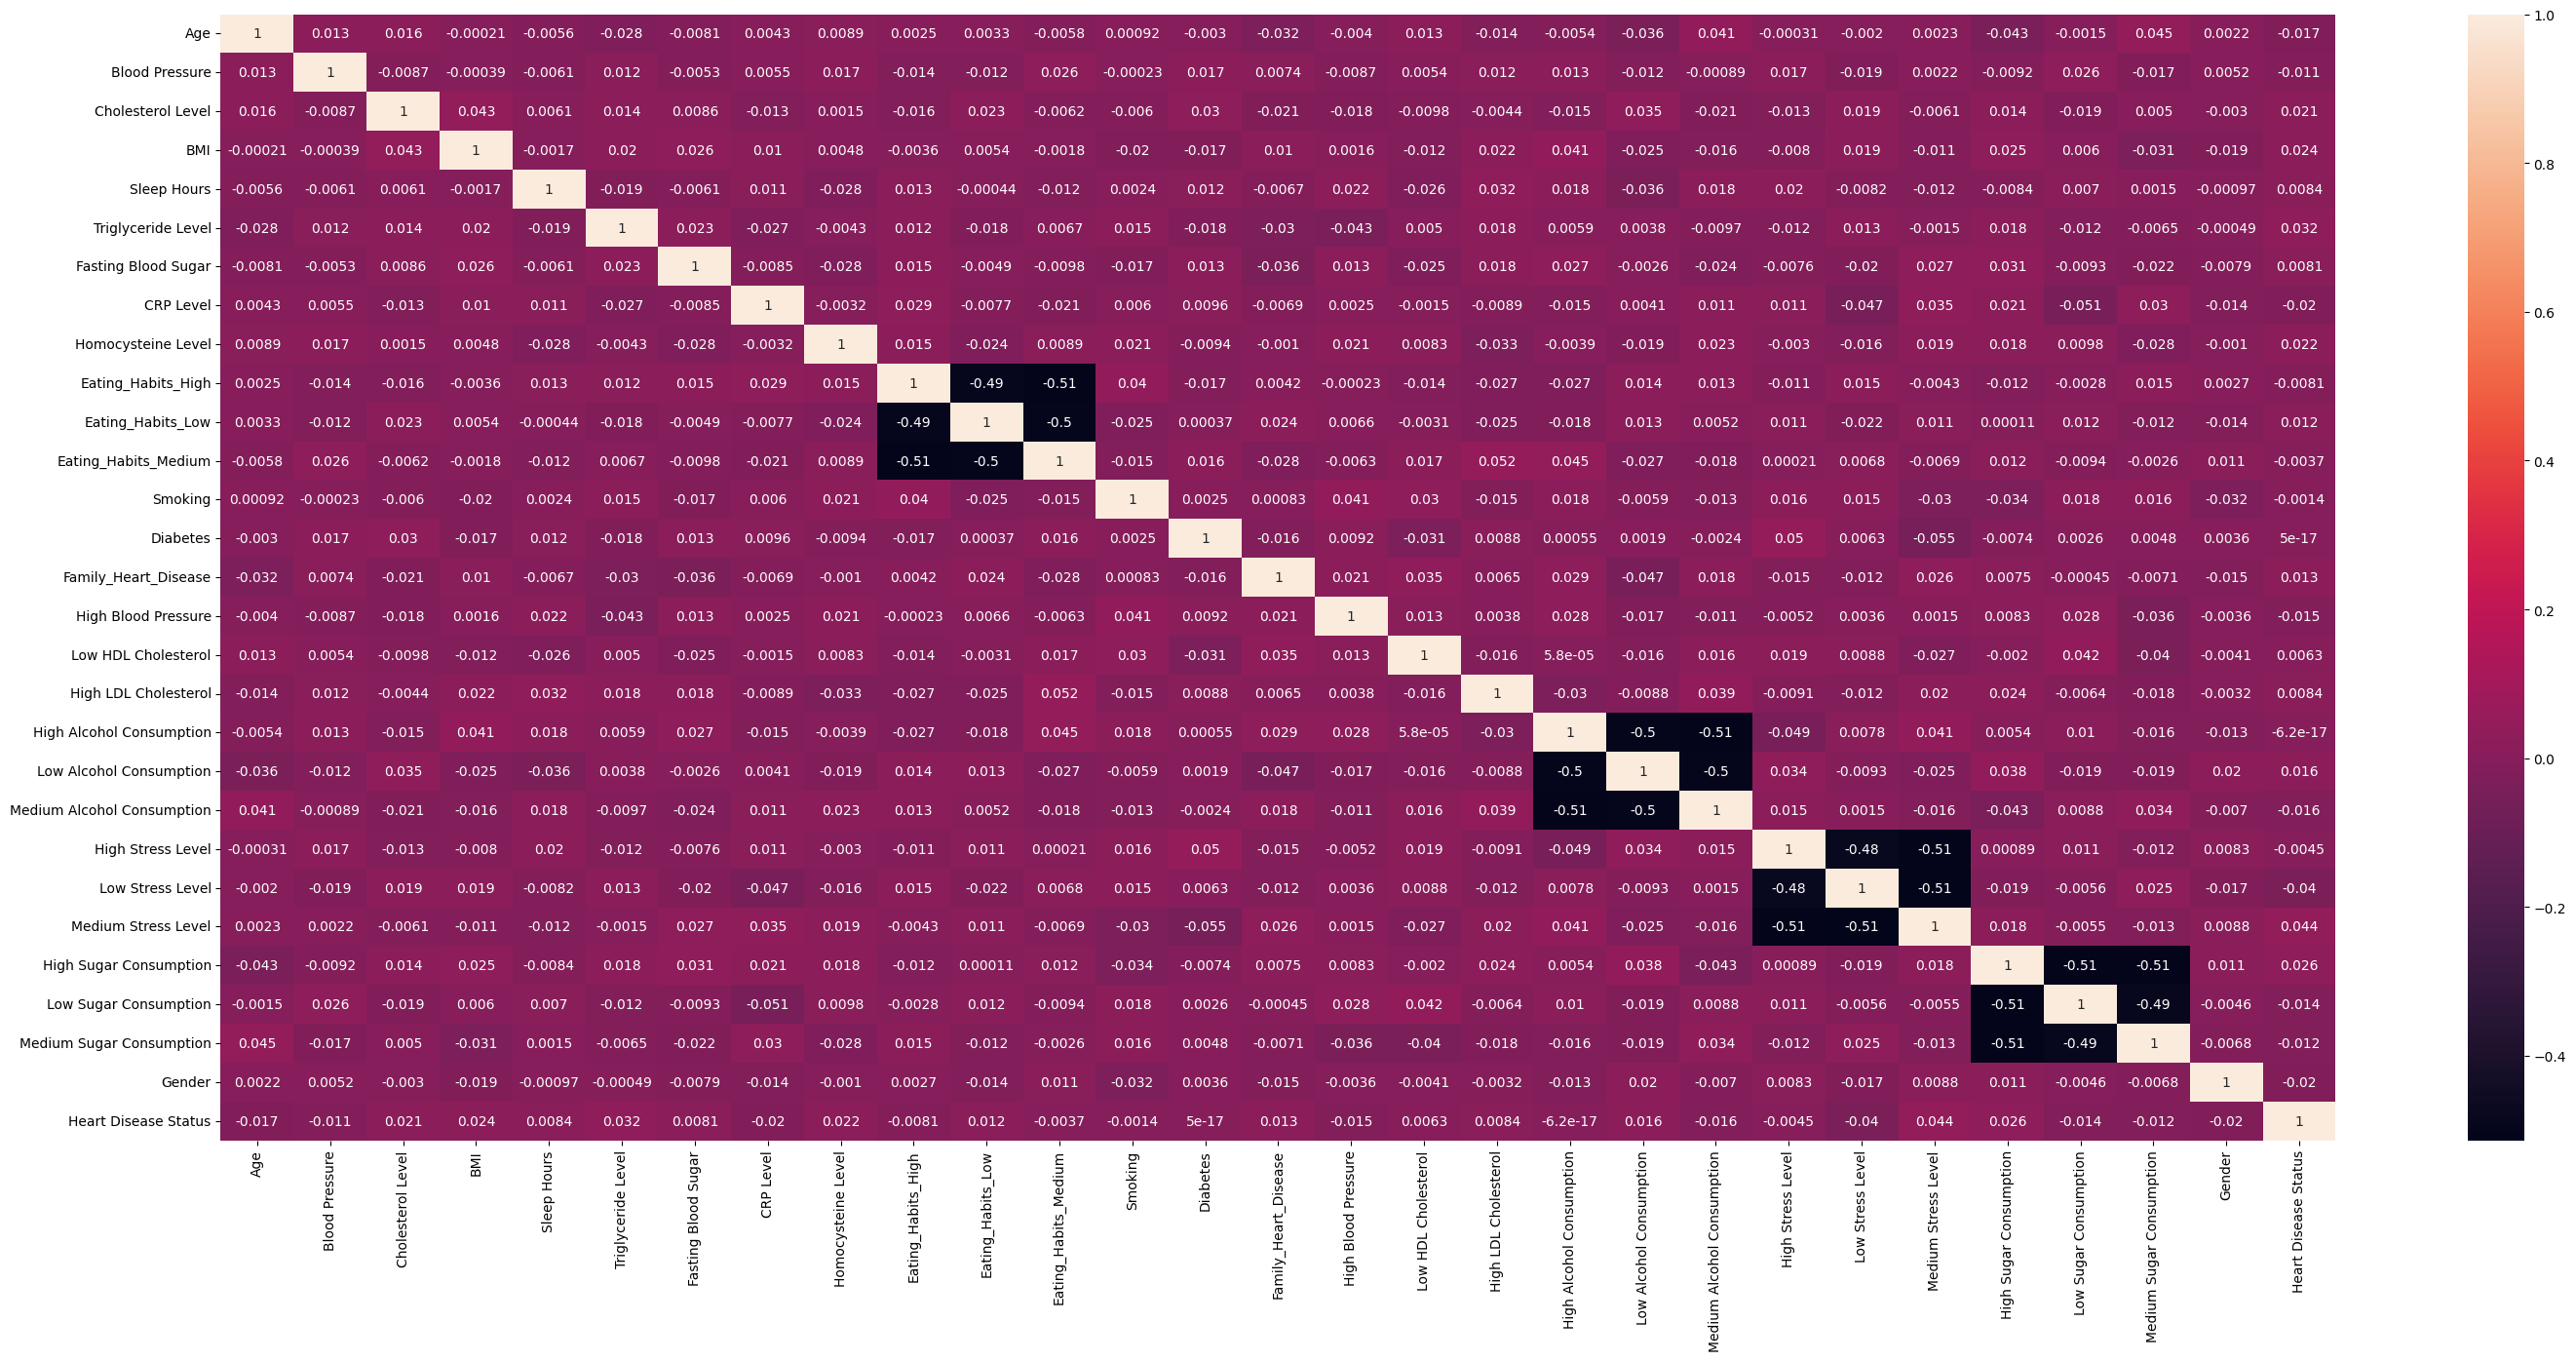

In [ ]:
plt.figure(figsize=(35,15))
corr = data.corr()
sns.heatmap(corr, annot=True)
plt.show()


In [ ]:

# training and normalization of data
X = data.iloc[:,:-1]
Y = data.iloc[:,-1:]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.10, random_state=1)

# SScaler = StandardScaler()
# X_train = SScaler.fit_transform(X_train)
# X_test = SScaler.fit_transform(X_test)

In [ ]:
from sklearn.svm import SVC
svc= SVC()
svc.fit(X_train,Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [ ]:
X_test

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Eating_Habits_High,...,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender
1366,18.0,124.0,195.0,25.284558,9.716982,158.0,94.0,8.636492,13.991799,False,...,False,True,False,False,True,False,False,False,True,True
8889,52.0,166.0,281.0,32.557536,5.123857,357.0,115.0,3.619866,14.778810,True,...,True,False,False,True,False,False,False,True,False,False
8085,31.0,180.0,217.0,34.543107,7.384693,287.0,100.0,4.222920,7.259895,False,...,False,False,True,True,False,False,True,False,False,False
9250,24.0,149.0,187.0,26.899562,5.932493,282.0,123.0,7.623746,9.085076,False,...,True,False,False,False,False,True,True,False,False,False
9418,39.0,159.0,248.0,32.446892,8.860225,205.0,153.0,9.774237,8.353404,False,...,True,False,False,False,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8382,34.0,169.0,299.0,38.037595,8.390235,189.0,99.0,0.611522,17.434174,False,...,False,True,False,True,False,False,False,False,True,True
1517,41.0,137.0,271.0,39.760296,6.719749,199.0,88.0,2.647180,5.721677,False,...,True,False,False,False,False,True,False,False,True,False
2051,42.0,166.0,257.0,33.256763,8.948679,337.0,147.0,9.446211,12.050883,True,...,False,True,False,False,True,False,False,False,True,False
1440,43.0,133.0,193.0,30.018054,5.970241,300.0,112.0,3.566071,16.845132,False,...,True,False,False,False,False,True,False,True,False,True


In [ ]:
Y_test

,Heart Disease Status
1366,False
8889,True
8085,True
9250,True
9418,True
...,...
8382,True
1517,False
2051,False
1440,False


In [ ]:
Y_pred = svc.predict(X_test)
Y_pred



array([False,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
       False, False,  True,  True, False,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True, False,  True,
       False,  True,  True,  True,  True,  True,  True, False,  True,
       False, False,

In [ ]:
pd.DataFrame({'Results':list(Y_pred)})

,Results
0,False
1,True
2,True
3,True
4,True
...,...
282,True
283,True
284,True
285,True


In [ ]:
#test accu
svc_accuracy= round(accuracy_score(Y_test,Y_pred),2)*100 # Accuracy
svc_accuracy

48.0

In [ ]:
#train accu
Y_pred = svc.predict(X_train)
svc_accuracy1= round(accuracy_score(Y_train,Y_pred),2)*100 # Accuracy
svc_accuracy1

51.0

#Testing

In [ ]:
d = X_test.iloc[50:51]
d

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Eating_Habits_High,...,High Alcohol Consumption,Low Alcohol Consumption,Medium Alcohol Consumption,High Stress Level,Low Stress Level,Medium Stress Level,High Sugar Consumption,Low Sugar Consumption,Medium Sugar Consumption,Gender
366,33.0,145.0,272.0,36.484414,5.688719,249.0,128.0,2.252066,5.263415,True,...,False,False,True,False,True,False,False,False,True,False


In [ ]:
Y_test.iloc[50:51]

,Heart Disease Status
366,False


In [ ]:
Y_pred = svc.predict(X_test.iloc[50:51])
Y_pred

array([ True])

In [ ]:
# Pregnancies = int(input("Enter Pregnancies = "))
# Glucose = int(input("Enter Glucose = "))
# BloodPressure = int(input("Enter BloodPressure = "))
# SkinThickness = int(input("Enter SkinThickness = "))
# Insulin = float(input("Enter Insulin = "))
# BMI = float(input("Enter BMI = "))
# DiabetesPedigreeFunction = float(input("Enter DiabetesPedigreeFunction = "))
# Age = int(input("Enter Age = "))

# new_data = {'Pregnancies':[Pregnancies],
#             'Glucose':[Glucose],
#             'BloodPressure':[BloodPressure],
#             'SkinThickness':[SkinThickness],
#             'Insulin':[Insulin],
#             'BMI':[BMI],
#             'DiabetesPedigreeFunction':[DiabetesPedigreeFunction],
#             'Age':[Age]
#             }
# d = pd.DataFrame(new_data)

In [ ]:
# d

In [ ]:
# Y_score = svc.predict(d)
# print(Y_score)

yes 132
No 155


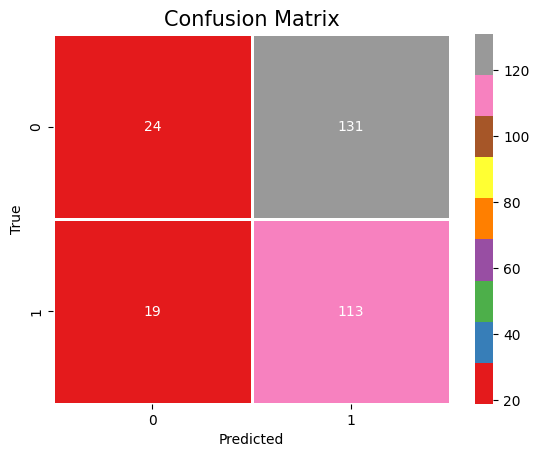

In [ ]:
# def impressions(model,accuracy):
# print('Mean squared error: ', round(mean_squared_error(Y_test,Y_pred),3))
Y_pred = svc.predict(X_test)

cm=confusion_matrix(Y_test,Y_pred)

class_label = [0, 1]
print("yes",len(Y_test[Y_test['Heart Disease Status'] == True]))
print("No",len(Y_test[Y_test['Heart Disease Status'] == False]))

df_cm = pd.DataFrame(cm, index=class_label,columns=class_label)
df_cm
sns.heatmap(df_cm,annot=True,cmap='Set1',linewidths=2,fmt = 'd')
plt.title("Confusion Matrix",fontsize=15)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# cm


In [ ]:
report=classification_report(Y_test,Y_pred)
print(report)

              precision    recall  f1-score   support

       False       0.56      0.15      0.24       155
        True       0.46      0.86      0.60       132

    accuracy                           0.48       287
   macro avg       0.51      0.51      0.42       287
weighted avg       0.51      0.48      0.41       287

